In [1]:
import os
import pandas as pd

In [2]:
methods_names = {
    "dist_linguistic_confidence": "Dist. Ling. Conf.",
    "dist_semantic_uncertainty": "Dist. Semantic Unc.",
    "dist_lnll": "Dist. Token Prob"
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuADv2.0",
    "truth_qa": "TruthfulQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

In [3]:
results_dir = f"/hdd/ivny/hedged_qa_in_domain_calibration"

# list all leaf nodes in results_dir
leaf_dirs = []
for root, dirs, files in os.walk(results_dir):
    if not dirs:  # if there are no subdirectories, it's a leaf node
        leaf_dirs.append(root)

all_records = []
for leaf_dir in leaf_dirs:
    _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
    csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_performance.csv"), index_col=0)
    csv_records = csv_data.transpose().to_dict("records")

    for record in csv_records:
        record["dataset"] = dataset_map.get(dataset_name, dataset_name)
        record["model"] = model_name_map.get(model_name, model_name)

    all_records.extend(csv_records)

In [4]:
mean_df = pd.DataFrame(all_records).drop(columns=["dataset"]).groupby(["model"]).mean().reset_index()
mean_df

,model,original_lc_generalised_ECE,original_lc_faithfulness_divergence,original_lc_ece_mean,original_lc_dAUROC,original_lc_auroc_mean,original_tp_generalised_ECE,original_tp_faithfulness_divergence,original_tp_ece_mean,original_tp_dAUROC,...,calibrated_tp_rewritten_lc_generalised_ECE,calibrated_tp_rewritten_lc_faithfulness_divergence,calibrated_tp_rewritten_lc_ece_mean,calibrated_tp_rewritten_lc_dAUROC,calibrated_tp_rewritten_lc_auroc_mean,calibrated_su_rewritten_lc_generalised_ECE,calibrated_su_rewritten_lc_faithfulness_divergence,calibrated_su_rewritten_lc_ece_mean,calibrated_su_rewritten_lc_dAUROC,calibrated_su_rewritten_lc_auroc_mean
0,GPT-OSS-20B,0.267796,1.674217,0.242987,0.549967,0.553725,0.129221,0.727464,0.100243,0.573283,...,0.154103,0.808931,0.109064,0.551167,0.572930,0.118776,0.617116,0.093610,0.626633,0.654105
1,Llama-3.1-8B-Inst.,0.216245,1.103337,0.188842,0.583767,0.601481,0.123846,0.496288,0.115135,0.625067,...,0.122247,0.541770,0.062614,0.603267,0.635623,0.089601,0.511940,0.060950,0.620033,0.646754
2,Mistral-7B-Inst.,0.301976,1.769188,0.275405,0.527900,0.533465,0.202151,17.486270,0.187938,0.604667,...,0.124333,0.531285,0.074237,0.573067,0.590535,0.122922,0.541547,0.091491,0.566900,0.590424
3,Qwen3-8B-Inst.,0.281860,1.732306,0.260191,0.535533,0.556530,0.336337,122.392183,0.335116,0.585783,...,0.132537,0.575611,0.091506,0.540333,0.558501,0.117055,0.572622,0.083963,0.569467,0.591631


In [5]:
mean_df.columns.tolist()

['model',
 'original_lc_generalised_ECE',
 'original_lc_faithfulness_divergence',
 'original_lc_ece_mean',
 'original_lc_dAUROC',
 'original_lc_auroc_mean',
 'original_tp_generalised_ECE',
 'original_tp_faithfulness_divergence',
 'original_tp_ece_mean',
 'original_tp_dAUROC',
 'original_tp_auroc_mean',
 'original_su_generalised_ECE',
 'original_su_faithfulness_divergence',
 'original_su_ece_mean',
 'original_su_dAUROC',
 'original_su_auroc_mean',
 'calibrated_lc_generalised_ECE',
 'calibrated_lc_faithfulness_divergence',
 'calibrated_lc_ece_mean',
 'calibrated_lc_dAUROC',
 'calibrated_lc_auroc_mean',
 'calibrated_tp_generalised_ECE',
 'calibrated_tp_faithfulness_divergence',
 'calibrated_tp_ece_mean',
 'calibrated_tp_dAUROC',
 'calibrated_tp_auroc_mean',
 'calibrated_su_generalised_ECE',
 'calibrated_su_faithfulness_divergence',
 'calibrated_su_ece_mean',
 'calibrated_su_dAUROC',
 'calibrated_su_auroc_mean',
 'calibrated_lc_rewritten_lc_generalised_ECE',
 'calibrated_lc_rewritten_lc_fa

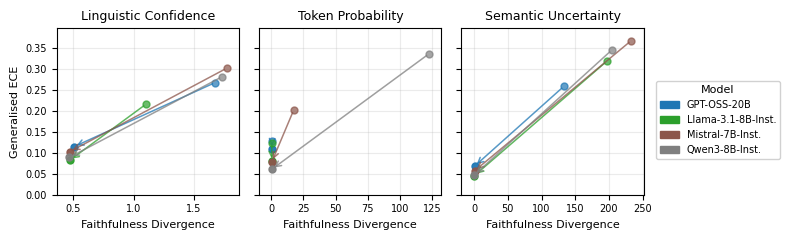

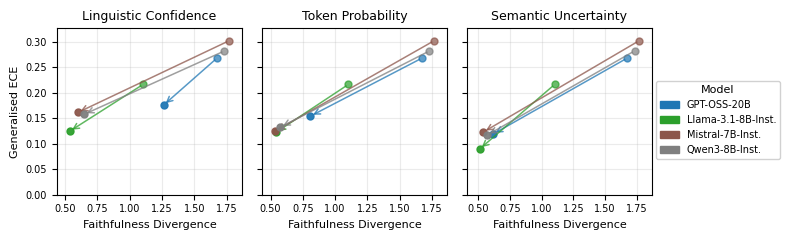

In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


def _plot_arrow_subplots(df, panels, filename):
    fig, axes = plt.subplots(1, 3, figsize=(8, 2.5), sharex=False, sharey=True)

    models = df["model"].unique().tolist()
    cmap = plt.colormaps["tab10"]
    model_colors = {m: cmap(i / max(len(models), 1)) for i, m in enumerate(models)}

    # Shared y-axis across panels, always anchored at 0.
    all_y_vals = []
    for p in panels:
        all_y_vals.extend(df[p["y_from"]].tolist())
        all_y_vals.extend(df[p["y_to"]].tolist())
    global_y_max = max(all_y_vals) if all_y_vals else 0.0
    y_top = max(global_y_max * 1.08, 1e-6)

    for ax, p in zip(axes, panels):
        x_vals = df[p["x_from"]].tolist() + df[p["x_to"]].tolist()
        finite_x_vals = [x for x in x_vals if np.isfinite(x)]
        if not finite_x_vals:
            continue
        x_min, x_max = min(finite_x_vals), max(finite_x_vals)

        for _, row in df.iterrows():
            x0, y0 = row[p["x_from"]], row[p["y_from"]]
            x1, y1 = row[p["x_to"]], row[p["y_to"]]
            color = model_colors[row["model"]]

            if not (np.isfinite(x0) and np.isfinite(x1)):
                continue

            ax.scatter(x0, y0, color=color, s=25, alpha=0.7, zorder=3)
            ax.scatter(x1, y1, color=color, s=25, alpha=0.95, zorder=3)
            ax.annotate(
                "",
                xy=(x1, y1),
                xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", lw=1.1, alpha=0.75, color=color),
            )

        # Linear x-axis for faithfulness divergence.
        if np.isclose(x_min, x_max):
            x_pad = max(abs(x_min) * 0.1, 1e-6)
        else:
            x_pad = (x_max - x_min) * 0.08
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(0, y_top)

        ax.set_title(p["title"], fontsize=9)
        ax.grid(alpha=0.25, which="major")
        ax.set_xlabel("Faithfulness Divergence", fontsize=8)
        ax.tick_params(labelsize=7)

    axes[0].set_ylabel("Generalised ECE", fontsize=8)

    handles = [mpatches.Patch(color=model_colors[m], label=m) for m in models]
    fig.legend(
        handles=handles,
        title="Model",
        title_fontsize=8,
        fontsize=7,
        loc="center left",
        ncol=1,
        bbox_to_anchor=(0.82, 0.5),
        frameon=True,
        framealpha=0.9,
        edgecolor="#cccccc",
    )

    fig.tight_layout(rect=[0, 0, 0.84, 1])
    plt.savefig(filename + ".pdf", dpi=300, bbox_inches="tight")


# Plot 1: original -> calibrated within each method (lc, tp, su)
panels_plot1 = [
    {
        "title": "Linguistic Confidence",
        "x_from": "original_lc_faithfulness_divergence",
        "y_from": "original_lc_generalised_ECE",
        "x_to": "calibrated_lc_faithfulness_divergence",
        "y_to": "calibrated_lc_generalised_ECE",
    },
    {
        "title": "Token Probability",
        "x_from": "original_tp_faithfulness_divergence",
        "y_from": "original_tp_generalised_ECE",
        "x_to": "calibrated_tp_faithfulness_divergence",
        "y_to": "calibrated_tp_generalised_ECE",
    },
    {
        "title": "Semantic Uncertainty",
        "x_from": "original_su_faithfulness_divergence",
        "y_from": "original_su_generalised_ECE",
        "x_to": "calibrated_su_faithfulness_divergence",
        "y_to": "calibrated_su_generalised_ECE",
    },
]

_plot_arrow_subplots(
    mean_df,
    panels_plot1,
    "in_domain_calibration_hedged_qa_signal_space",
)


# Plot 2: original LC -> rewritten LC using calibrator from lc / tp / su
panels_plot2 = [
    {
        "title": "Linguistic Confidence",
        "x_from": "original_lc_faithfulness_divergence",
        "y_from": "original_lc_generalised_ECE",
        "x_to": "calibrated_lc_rewritten_lc_faithfulness_divergence",
        "y_to": "calibrated_lc_rewritten_lc_generalised_ECE",
    },
    {
        "title": "Token Probability",
        "x_from": "original_lc_faithfulness_divergence",
        "y_from": "original_lc_generalised_ECE",
        "x_to": "calibrated_tp_rewritten_lc_faithfulness_divergence",
        "y_to": "calibrated_tp_rewritten_lc_generalised_ECE",
    },
    {
        "title": "Semantic Uncertainty",
        "x_from": "original_lc_faithfulness_divergence",
        "y_from": "original_lc_generalised_ECE",
        "x_to": "calibrated_su_rewritten_lc_faithfulness_divergence",
        "y_to": "calibrated_su_rewritten_lc_generalised_ECE",
    },
]

_plot_arrow_subplots(
    mean_df,
    panels_plot2,
    "in_domain_calibration_hedged_qa_linguistic_space",
)